# 🌲 Deforestation Detection & Land-Cover Change Analysis
This notebook implements a multitemporal change detection pipeline to identify forest loss (deforestation) in a study region between two acquisitions.

### Workflow
1. **Load imagery** for Year A (2018) and Year B (2022).
2. **Generate land-cover maps** for both years using our CNN classification engine.
3. **Compute the Transition Matrix** to analyze overall land-cover dynamics.
4. **Isolate Forest -> Non-Forest transitions** to produce a binary deforestation mask.
5. **Generate a red-overlay deforestation map** for publication/reporting.


## 1. Introduction

### Deforestation & Change Detection
Deforestation is a primary contributor to biodiversity loss and global carbon emissions. Change detection in remote sensing compares co-registered satellite images acquired at different times to identify where changes have occurred. Post-classification comparison is a robust technique: we classify both images independently, then compare the classes pixel-by-pixel (or patch-by-patch).

### Forest -> Non-Forest Transitions
Stable forests remain classified as `Forest` in both Year A and Year B. Deforestation is defined specifically as the transition from `Forest` to any non-forest class (e.g. `Pasture`, `AnnualCrop`, `Industrial`, `Residential`, or `Highway`).


## 2. Load Modular Code & Setup Path


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch

from src.models import create_model
from src.inference import LandCoverPredictor, LandCoverMapper
from src.change_detection import ChangeDetector, DeforestationDetector
from src.utils import generate_demo_data, plot_transition_matrix_heatmap, plot_forest_area_comparison

os.makedirs("reports/figures", exist_ok=True)


## 3. Load Multitemporal Sentinel-2 Imagery
We load the images for Year A (2018) and Year B (2022). If missing, they are generated using our EuroSAT tiling tool.


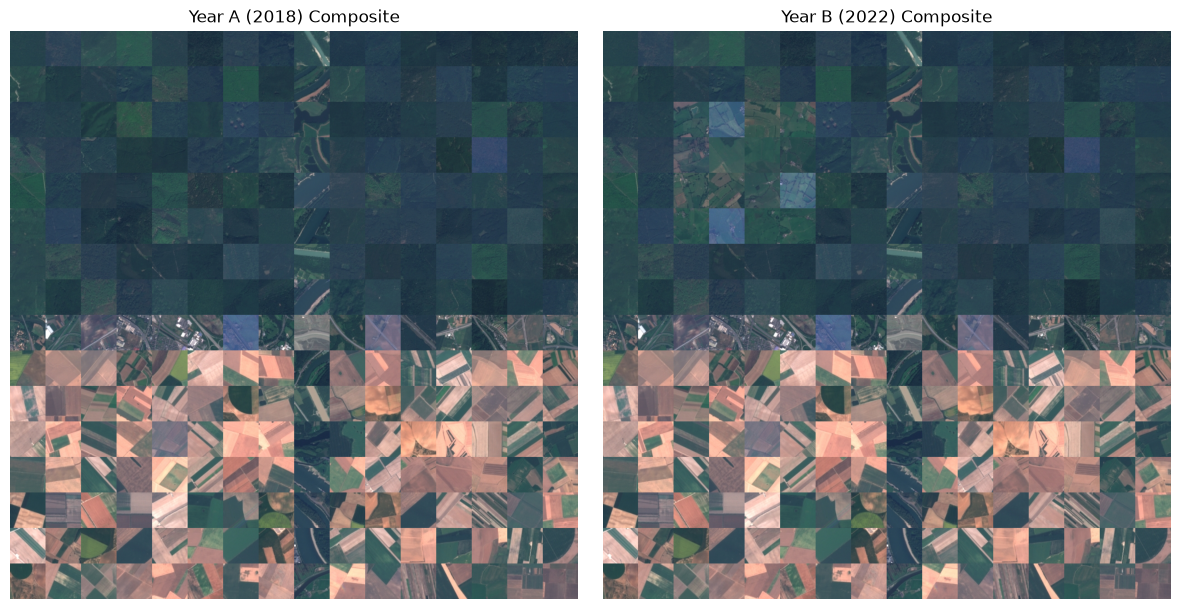

In [2]:
data_dir = "../data/demo"
y1_file = os.path.join(data_dir, "sentinel2_2018.png")
y2_file = os.path.join(data_dir, "sentinel2_2022.png")

if not (os.path.exists(y1_file) and os.path.exists(y2_file)):
    print("Demo datasets missing. Generating tile composites...")
    generate_demo_data(data_dir)

img_a = Image.open(y1_file)
img_b = Image.open(y2_file)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_a)
plt.title("Year A (2018) Composite")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_b)
plt.title("Year B (2022) Composite")
plt.axis("off")

plt.tight_layout()
plt.savefig("reports/figures/sentinel2_temporal_comparison.png", dpi=300)
plt.show()


## 4. Generate Land Cover Maps
We load the model (defaulting to ResNet-18 checkpoint if available) and run land cover mapping on both Year A and Year B scenes.


In [3]:
# Load best available model
checkpoint_options = [
    ("resnet18", "../outputs/checkpoints/resnet18/best_model.pth"),
    ("googlenet", "../outputs/checkpoints/googlenet/best_model.pth")
]
model_name = "resnet18"
checkpoint_path = None
for name, path in checkpoint_options:
    if os.path.exists(path):
        model_name = name
        checkpoint_path = path
        break

model = create_model(model_name, num_classes=10)
predictor = LandCoverPredictor(model=model, checkpoint_path=checkpoint_path)
mapper = LandCoverMapper(predictor=predictor, patch_size=64, stride=64)

print("Mapping Year A...")
map_a = mapper.generate_map(img_a, batch_size=32)
print("Mapping Year B...")
map_b = mapper.generate_map(img_b, batch_size=32)

# Save land cover maps
map_a["prediction_map"].save("reports/figures/landcover_map_2018.png")
map_b["prediction_map"].save("reports/figures/landcover_map_2022.png")


Mapping Year A...
Mapping Year B...


## 5. Change Detection & Transition Matrix
We compute patch-level transitions and build the land cover transition matrix heatmap. This matrix details exactly how classes shifted over time.


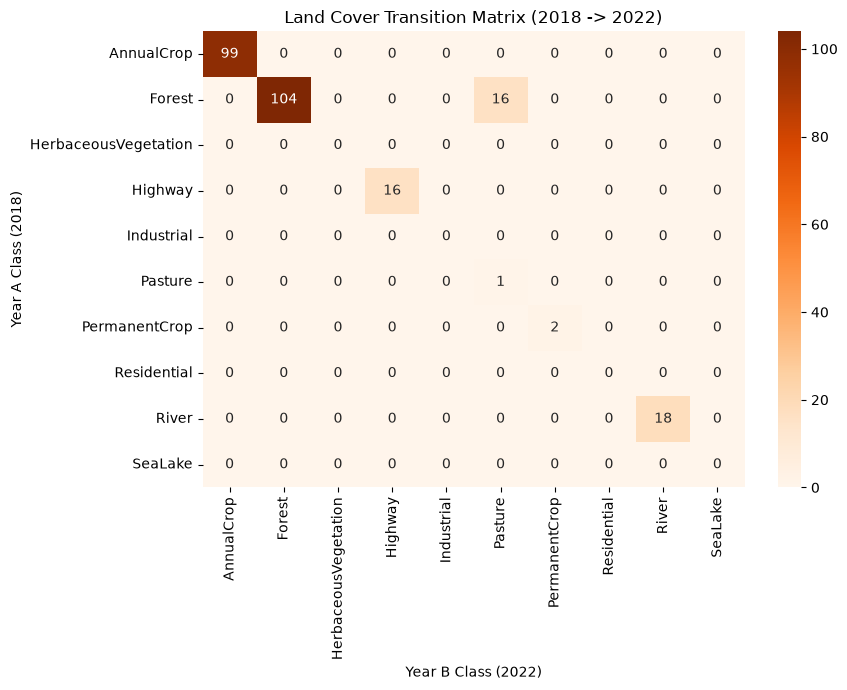

In [4]:
detector = ChangeDetector(confidence_threshold=0.0)
changes = detector.detect_patch_changes(map_a, map_b)

# Compute and save transition matrix
matrix = detector.compute_transition_matrix(changes)
plot_transition_matrix_heatmap(matrix, detector.classes, "reports/figures/transition_matrix_heatmap.png")

# Display heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Oranges", 
            xticklabels=detector.classes, yticklabels=detector.classes)
plt.title("Land Cover Transition Matrix (2018 -> 2022)")
plt.ylabel("Year A Class (2018)")
plt.xlabel("Year B Class (2022)")
plt.tight_layout()
plt.show()


## 6. Deforestation Mask Generation & Visual Overlay
We identify specifically `Forest -> Non-Forest` transitions using `DeforestationDetector`. We generate a binary deforestation mask and plot it as a red bounding box overlay on top of Year B's optical image.


Total Deforested Patches: 16


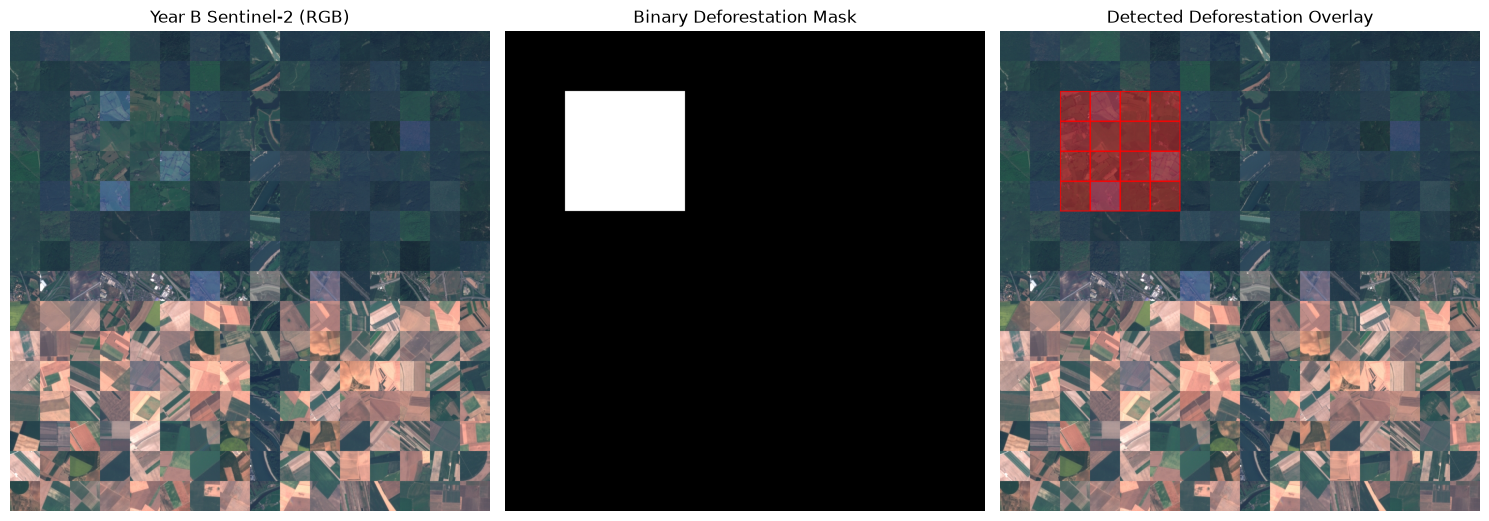

In [5]:
defor_detector = DeforestationDetector(forest_class="Forest")
pred_defor_mask = defor_detector.detect_deforestation(changes)

print(f"Total Deforested Patches: {sum(pred_defor_mask)}")

# Generate binary mask and overlay image
bin_mask_img = defor_detector.generate_binary_mask_image(pred_defor_mask, map_b["bboxes"], img_b.size)
overlay_img = defor_detector.draw_deforestation_overlay(img_b, pred_defor_mask, map_b["bboxes"])

# Save outputs
bin_mask_img.save("reports/figures/detected_deforestation_mask.png")
overlay_img.save("reports/figures/deforestation_overlay_visual.png")

# Plot results
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_b)
plt.title("Year B Sentinel-2 (RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bin_mask_img, cmap='gray')
plt.title("Binary Deforestation Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title("Detected Deforestation Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Change Statistics & Area Calculation
Each patch is 64x64 pixels. In Sentinel-2, RGB bands have a spatial resolution of 10 meters per pixel, meaning each patch is 640m x 640m. Thus, the physical surface area of each patch is:

$$\text{Area} = 640\text{ m} \times 640\text{ m} = 409,600\text{ m}^2 = 40.96\text{ hectares}$$

We calculate forest loss and relative deforestation percentage using this scaling factor.


In [6]:
patch_area_ha = (64 * 10) ** 2 / 10000.0  # 40.96 ha
total_patches = len(pred_defor_mask)
total_area_ha = total_patches * patch_area_ha

forest_a_patches = sum(1 for c in map_a["classes"] if c == "Forest")
forest_b_patches = sum(1 for c in map_b["classes"] if c == "Forest")
forest_loss_patches = sum(pred_defor_mask)

forest_a_ha = forest_a_patches * patch_area_ha
forest_b_ha = forest_b_patches * patch_area_ha
forest_loss_ha = forest_loss_patches * patch_area_ha
loss_pct = (forest_loss_ha / forest_a_ha * 100) if forest_a_ha > 0 else 0

print("="*50)
print("            STATISTICS REPORT")
print("="*50)
print(f"Total Survey Area          : {total_area_ha:.2f} ha")
print(f"Forest Area (Year A)       : {forest_a_ha:.2f} ha ({forest_a_patches} patches)")
print(f"Forest Area (Year B)       : {forest_b_ha:.2f} ha ({forest_b_patches} patches)")
print(f"Forest Deforested          : {forest_loss_ha:.2f} ha ({forest_loss_patches} patches)")
print(f"Deforestation Percentage   : {loss_pct:.2f}%")
print("="*50)

# Save forest comparison plot
plot_forest_area_comparison(forest_a_ha, forest_b_ha, "reports/figures/forest_area_comparison.png")


            STATISTICS REPORT
Total Survey Area          : 10485.76 ha
Forest Area (Year A)       : 4915.20 ha (120 patches)
Forest Area (Year B)       : 4259.84 ha (104 patches)
Forest Deforested          : 655.36 ha (16 patches)
Deforestation Percentage   : 13.33%


## 8. Discussion & Conclusion

### Challenges in Satellite Change Detection
- **Seasonal Vegetation Shifts**: Changes in canopy moisture or agricultural cycles can be misclassified as land cover changes.
- **Cloud & Shade Obstruction**: Cloud cover blocks optical measurements, while shadows mimic water/river classes. Temporal compositing (like median filtering) helps reduce these effects.
- **Image Registration**: Misalignments of even a few pixels can cause artificial changes along roads or riverbanks.

In the next notebook, **Validation.ipynb**, we will validate our model-derived forest loss mask against the Hansen Global Forest Change reference map to compute standard performance metrics.
